# Generate TestSet Questions to evaluate your RAG pipeline

> Tech Stack: [LangGraph](https://github.com/langchain-ai/langchain), [Qdrant](https://github.com/qdrant/qdrant), [OpenAI](https://platform.openai.com/) and [TruLens](https://github.com/truera/trulens)

> TruLens benchmark to generate the questions

### Installation

In [ ]:
!pip install langgraph langchain-community langchain-openai langchain-qdrant pypdfium2
!pip install trulens "trulens-benchmark"
!pip install trulens-providers-openai
!pip install trulens-apps-langgraph

## Initial Setup

Install the required libraries and configure API keys for OpenAI and Qdrant. A TruLens session is initialized here to track and store all evaluation data throughout the notebook.

- Get OpenAI API Key: [https://platform.openai.com/](https://platform.openai.com/)
- Get Qdrant API Key and Endpoint URL: [https://cloud.qdrant.io/](https://cloud.qdrant.io/)

In [10]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

### Overview

We will generate a dataset to evaluate the RAG pipeline built using LangGraph and Qdrant, and assess it using the RAG Triad evaluation metrics.

In [11]:
from langchain_community.document_loaders import PyPDFium2Loader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient, models

In [12]:
from trulens.core import TruSession

session = TruSession()
session.reset_database()

Updating app_name and app_version in apps table: 0it [00:00, ?it/s]
Updating app_id in records table: 0it [00:00, ?it/s]
Updating app_json in apps table: 0it [00:00, ?it/s]


## Data loading and chunking

The Economic Survey 2025-26 report is downloaded and parsed using PyPDFium2. It is then split into overlapping chunks using Langchain's RecursiveCharacterTextSplitter to prepare the text for embedding and retrieval.

> Economic Survey 2025-26 by Government of India: [Survey Report](https://www.indiabudget.gov.in/economicsurvey/doc/eschapter/epreface.pdf)

In [9]:
!curl -L -A "Mozilla/5.0" https://www.indiabudget.gov.in/economicsurvey/doc/eschapter/epreface.pdf -o survey.pdf

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3973k  100 3973k    0     0  1545k      0  0:00:02  0:00:02 --:--:-- 1546k


In [13]:
path = "survey.pdf"
loader = PyPDFium2Loader(path)
docs = loader.load()

In [14]:
print(len(docs))

51


In [15]:
print(docs[1].page_content)

Government of India
Ministry of Finance
Department of Economic Affairs
Economic Division
Kartavya Bhavan-1
New Delhi-110001
January, 2026
Economic 
Survey 2025-26



In [16]:
print(docs[1].metadata)

{'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20260128193114', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'source': 'survey.pdf', 'total_pages': 51, 'page': 1}


In [17]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1536,
    chunk_overlap = 0,
)
chunks = text_splitter.split_documents(docs)

## Setup your Qdrant Vector Database

A Qdrant collection is configured using dense vectors generated from OpenAI embeddings, enabling semantic search based on meaning and contextual similarity. Each document or chunk is converted into its corresponding embedding and indexed within the collection along with its associated metadata.

During retrieval, the query is embedded into the same vector space and matched against the indexed vectors to return the most semantically relevant results.

In [18]:
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [19]:
print(len(embeddings_model.embed_query("this is testing to check dimensions")))

1536


In [20]:
collection_name = "economicv1"

In [21]:
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

In [22]:
client.create_collection(
    collection_name = collection_name,
    vectors_config = {
        "dense" : models.VectorParams(
            size = 1536,
            distance = models.Distance.COSINE
        )
    }
)

True

In [23]:
db = QdrantVectorStore(
    client = client,
    collection_name = collection_name,
    embedding = embeddings_model,
    vector_name ="dense",
)

### Test the retriver

In [ ]:
db.add_documents(documents=chunks) # just run it once. After the data is indexed, you need not have to add_documents again

In [25]:
query = "what is Financial Time wrote on the eve of Christmas 2025"
relevant_docs = db.max_marginal_relevance_search(query)

In [26]:
relevant_docs[0].page_content

'ix\nremains integrated yet increasingly distrustful. One could attach a subjective probability of \naround 40% to 45% to this scenario unfolding in 2026. Reflecting this is the Global Economic\nPolicy Uncertainty Index2\n, which is near its worst readings of 2020, excluding the sharp spike\nin April 2025 at the introduction of the reciprocal tariffs. Fear lingers. That brings us to the\nsecond scenario.\nIn this scenario, the probability of a disorderly multipolar breakdown rises materially\nand cannot be treated as a tail risk. Under this outcome, strategic rivalry intensifies, the\nRussia–Ukraine conflict remains unresolved in a destabilising form, and collective security\narrangements unravel. Trade becomes increasingly explicitly coercive, sanctions and counter\ufffemeasures proliferate, supply chains are realigned under political pressure, and financial\nstress events are transmitted across borders with fewer buffers and weaker institutional shock\nabsorbers. In this world, polic

> Convert to the retriever: i.e., Langchain object

In [27]:
retriever = db.as_retriever()

In [28]:
print(retriever.invoke(query)[0].page_content)

ix
remains integrated yet increasingly distrustful. One could attach a subjective probability of 
around 40% to 45% to this scenario unfolding in 2026. Reflecting this is the Global Economic
Policy Uncertainty Index2
, which is near its worst readings of 2020, excluding the sharp spike
in April 2025 at the introduction of the reciprocal tariffs. Fear lingers. That brings us to the
second scenario.
In this scenario, the probability of a disorderly multipolar breakdown rises materially
and cannot be treated as a tail risk. Under this outcome, strategic rivalry intensifies, the
Russia–Ukraine conflict remains unresolved in a destabilising form, and collective security
arrangements unravel. Trade becomes increasingly explicitly coercive, sanctions and counter￾measures proliferate, supply chains are realigned under political pressure, and financial
stress events are transmitted across borders with fewer buffers and weaker institutional shock
absorbers. In this world, policy becomes more nat

## Build your LangGraph RAG workflow - Answer Generation

In [29]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [30]:
llm = ChatOpenAI(model_name="gpt-5-mini")

In [31]:
SYSTEM_PROMPT = """
  You are an expert financial analyst specializing in corporate finance.
  You should be respectful and truthful while answering the user questions, if not you will face serious consequences.

  The only source information you have is the context provided, if the user query is not from the context
  Just say `I dont know , not enough information provided.`
"""

In [32]:
USER_PROMPT = """
  Answer the USER QUERY based on the CONTEXT below.
  If the question cannot be answered using the information provided answer with `I dont know , not enough information provided.`

  <context>
  CONTEXT: {context}
  </context>

  <query>
  USER QUERY: {query}
  </query>
"""

In [33]:
from langgraph.graph import StateGraph # node and edges logic
from langgraph.graph import START,END
from typing import TypedDict, List

In [34]:
class RAGState(TypedDict):
    query: str
    context: List[str]
    answer: str

In [35]:
def search(state: RAGState) -> RAGState:
    relevant_docs = retriever.invoke(state['query'])

    context = []
    for doc in relevant_docs:
        context.append(doc.page_content)

    state['context'] = context
    return state

In [36]:
def answer(state: RAGState) -> RAGState:
    context = " ".join(state['context'])

    prompt_template = ChatPromptTemplate(
        messages = [
            ("system",SYSTEM_PROMPT),
            ("user",USER_PROMPT.format(context=context,
                                        query=state['query']))
        ],
    )
    answer = llm.invoke(prompt_template.format_messages())
    state['answer'] = answer.content
    return state

In [37]:
# Agent - workflows
workflow = StateGraph(RAGState)
workflow.add_node("search_context",search)
workflow.add_node("answer_generation",answer)

workflow.add_edge(START,"search_context")
workflow.add_edge("search_context","answer_generation")
workflow.add_edge("answer_generation",END)

graph = workflow.compile()

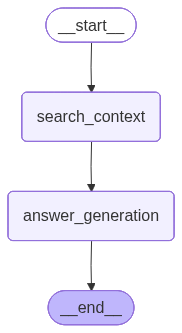

In [38]:
graph

In [39]:
def execute_graph(question: str) -> str:
    result = graph.invoke({"query": question})
    return result["answer"]

In [40]:
print(execute_graph(query))

On the eve of Christmas 2025, the Financial Times wrote, “Tech companies have moved more than $120bn of data centre spending off their balance sheets using special purpose rates, and the market’s growing assessment of geopolitical and financial tail risks.


## Generate Testset using TruLens

TruLens allows you to generate a test set of a specified breadth and depth, tailored to your app and data. The resulting test set will be a list of test prompts of length depth, for breadth categories of prompts. This test set will be made up of breadth X depth prompts organized by prompt category.

In [41]:
from trulens.providers.openai import OpenAI
from trulens.benchmark.generate.generate_test_set import GenerateTestSet

In [42]:
test = GenerateTestSet(app_callable = execute_graph)
provider = OpenAI()

In [43]:
test_set = test.generate_test_set(
    test_breadth=3,
    test_depth=2,
)

# breadth = 3 → generate 3 categories
# depth = 2 → generate 2 questions

In [44]:
test_set

{'Economic Growth': ["What is the Survey's revised estimate of India’s potential growth rate, and how does it compare with the estimate from three years ago?",
  'What nowcasting tool does the Survey introduce to assess near‑term GDP growth, and what type of indicators does it integrate?'],
 'Fiscal Consolidation': ['How does the Economic Survey say India’s fiscal credibility is supported by a deliberate shift toward capital formation and human capital investment?',
  'What risks to fiscal consolidation are identified from rising state revenue deficits and unconditional cash transfers (e.g., crowding out of capital expenditure and impacts on sovereign borrowing costs)?'],
 'Institutional Reform': ['Why does the Survey argue that process reforms are arguably more important than policy reforms for institutional reform?',
  'Which recent state-level initiatives does the Survey cite as grounds for optimism about institutional reform?']}

## Run Evals

Evaluate with TruLens feedbacks

In [45]:
import numpy as np
from trulens.core import Metric, Selector, Feedback
from trulens.otel.semconv.trace import SpanAttributes
from trulens.apps.langgraph import TruGraph

In [48]:
f_answer_relevance = Metric(
    implementation=provider.relevance_with_cot_reasons,
    name="Answer Relevance",
    selectors={
        "prompt": Selector(
            span_type=SpanAttributes.SpanType.RECORD_ROOT,
            span_attribute=SpanAttributes.RECORD_ROOT.INPUT,
        ),
        "response": Selector(
            span_type=SpanAttributes.SpanType.RECORD_ROOT,
            span_attribute=SpanAttributes.RECORD_ROOT.OUTPUT,
        ),
    },
)

f_context_relevance = Metric(
    implementation=provider.context_relevance_with_cot_reasons,
    name="Context Relevance",
    selectors={
        "question": Selector.select_record_input(),
        "context": Selector(
            span_type=SpanAttributes.SpanType.RETRIEVAL,
            span_attribute=SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS,
            collect_list=False,
        ),
    },
    agg=np.mean,
)

f_groundedness = Metric(
    implementation=provider.groundedness_measure_with_cot_reasons,
    name="Groundedness",
    selectors={
        "source": Selector(
            span_type=SpanAttributes.SpanType.RETRIEVAL,
            span_attribute=SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS,
            collect_list=True,
        ),
        "statement": Selector.select_record_output(),
    },
)

In [52]:
tru_recorder = TruGraph(
    graph,
    app_name="eval_testset",
    app_version="v1.0.0",
    feedbacks=[f_groundedness, f_answer_relevance, f_context_relevance],
)

instrumenting <class 'langgraph.graph.state.StateGraph'> for base <class 'langgraph.graph.state.StateGraph'>
instrumenting <class 'langgraph.graph.state.CompiledStateGraph'> for base <class 'langgraph.graph.state.CompiledStateGraph'>
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream
	instrumenting astream_events
	instrumenting stream
	instrumenting astream
	instrumenting astream_events
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream
	instrumenting stream_mode
instrumenting <class 'langgraph.graph.state.CompiledStateGraph'> for base <class 'langgraph.pregel.main.Pregel'>
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream
	instrumenting astream_events
	instrumenting stream
	instrumenting astream
	instrumenting astream_events
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream
	instrumenting stream_mode


In [53]:
with tru_recorder as recording:
    for topic, questions in test_set.items():
        for question in questions:
            graph.invoke({"query": question})

In [54]:
session.get_leaderboard()

,,Answer Relevance,latency,total_cost
app_name,app_version,,,
eval_testset,v1.0.0,0.0,7.56185,0.001275
